In [1]:
# load ipython-sql extension
%load_ext sql

In [2]:
# connect to database
%sql postgresql://postgres@localhost:5432/seattle_airbnb

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pprint import pprint

**1. Examine the missing values in the `listings` table**

In [4]:
%%sql result <<
SELECT *
FROM listings
WHERE (SELECT bool_or(value IS NULL)
       FROM jsonb_each_text(to_jsonb(listings))) = true; --covert rows into jsonb object and extract each field as a key-value pair


 * postgresql://postgres@localhost:5432/seattle_airbnb
1465 rows affected.
Returning data to local variable result


In [5]:
missing_vals = pd.DataFrame(result)
missing_vals.head(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,imputed_price
0,202251,Seattle Phinney Ridge Ballard,601266,Tim And Pam,Other neighborhoods,Phinney Ridge,47.67757,-122.36172,Entire home/apt,$275.00,30,34,2024-02-06,0.28,1,173,4,None,False
1,254340,Phinney Oasis-Ballard/Phinney,1336214,Kim,Other neighborhoods,Phinney Ridge,47.67632,-122.36019,Entire home/apt,$110.00,30,161,2019-10-31,1.05,1,52,0,None,False
2,303277,Hip Condo Private Deck East Lake Union - Long ...,1204187,Kara,Cascade,Eastlake,47.64424,-122.32397,Entire home/apt,$150.00,30,12,2021-02-12,0.08,1,170,0,None,False
3,340738,Victorian home on Capitol Hill,1729224,Marlow,Capitol Hill,Stevens,47.62376,-122.30494,Entire home/apt,$495.00,100,0,None,NaN,4,167,0,None,False
4,353110,Newly Remodeled Private Cottage in West Seattle!,1788284,Eric,West Seattle,North Admiral,47.58037,-122.39163,Entire home/apt,$89.00,30,92,2024-05-01,0.62,1,144,6,None,False
5,475361,NE Seattle Artist Treehouse Suite!,2342082,Marilyn,Lake City,Cedar Park,47.71652,-122.29126,Private room,$77.00,30,116,2022-10-28,0.79,1,179,0,None,False
6,552325,Lovely 2BR Apt on Portage Bay near UW + Eastlake,306615,Tara,Capitol Hill,Portage Bay,47.65043,-122.32021,Entire home/apt,$220.00,30,35,2024-05-16,0.26,2,193,2,None,False
7,654734,Downtown/Convention Center Condo,3294357,Grace,Downtown,First Hill,47.61311,-122.32947,Entire home/apt,$175.00,30,87,2024-05-01,0.61,1,214,5,None,False
8,708774,Clean and Comfortable Eastlake/Lake Union 1 BR,316200,William,Cascade,Eastlake,47.64000,-122.32412,Entire home/apt,$81.00,30,143,2024-06-02,1.02,7,112,5,None,False
9,723723,BAMBOO BUNGALOW,3740695,BleuPapillon,Central Area,Harrison/Denny-Blaine,47.61896,-122.28818,Entire home/apt,$524.00,30,50,2017-08-13,0.35,2,89,0,None,False


In [6]:
missing_cols = {}
for col in missing_vals.columns:
    missing_count = sum(missing_vals[col].isna())
    if missing_count > 0:
        missing_cols[col] = missing_count
pprint(missing_cols)

{'last_review': 841, 'license': 1130, 'reviews_per_month': 841}


In [7]:
%%sql
SELECT COUNT(*)
FROM listings
WHERE last_review IS NULL and reviews_per_month IS NULL
LIMIT 10;

 * postgresql://postgres@localhost:5432/seattle_airbnb
1 rows affected.


count
841


The missing values can be found in four columns: `price`, `last_review`, `reviews_per_month`, and `license`. It appears that without a last_review, there is also no information regarding reviews_per_month, which is intuitive. 

**2. Describe the data**

2.1 plot the distribution of the price

In [8]:
%%sql
price << 
SELECT price::NUMERIC
FROM listings
WHERE NOT(price IS NULL);

 * postgresql://postgres@localhost:5432/seattle_airbnb
6442 rows affected.
Returning data to local variable price


Text(0, 0.5, 'Count')

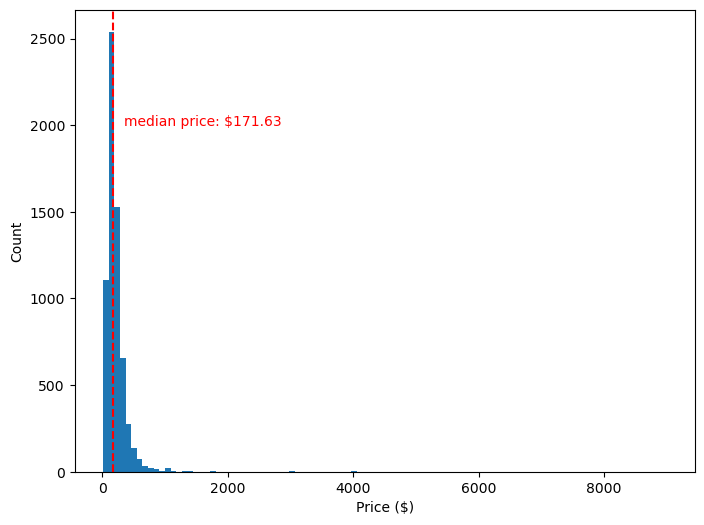

In [9]:
price = pd.DataFrame(price)
fig, ax = plt.subplots(figsize=(8,6))
ax.hist(x=price, bins=100)
ax.axvline(x=np.median(price), color='red', linestyle='dashed')
ax.text(x=np.median(price)*2, y=2000, s=f"median price: ${np.median(price)}", color='red')
ax.set_xlabel('Price ($)')
ax.set_ylabel('Count')


2.2 price by neighbourhood

In [10]:
%%sql
price_by_neighbourhood <<
SELECT neighbourhood_group, ROUND(AVG(price::NUMERIC), 2) AS avg_price
FROM listings
WHERE NOT price IS NULL
GROUP BY neighbourhood_group
ORDER BY AVG(price::NUMERIC) DESC;

 * postgresql://postgres@localhost:5432/seattle_airbnb
17 rows affected.
Returning data to local variable price_by_neighbourhood


In [11]:
price_by_neighbourhood = pd.DataFrame(price_by_neighbourhood)
price_by_neighbourhood

,neighbourhood_group,avg_price
0,Queen Anne,260.45
1,Cascade,241.91
2,Downtown,239.99
3,Central Area,233.08
4,Magnolia,227.97
5,Other neighborhoods,213.89
6,Ballard,207.86
7,Capitol Hill,203.55
8,West Seattle,197.66
9,Beacon Hill,193.58


2.3 price by room type

In [12]:
%%sql
price_by_roomtype <<
SELECT room_type, ROUND(AVG(price::NUMERIC), 2) AS avg_price, RANK() OVER(ORDER BY AVG(price::NUMERIC) DESC)
FROM listings
WHERE NOT price IS NULL
GROUP BY room_type;

 * postgresql://postgres@localhost:5432/seattle_airbnb
4 rows affected.
Returning data to local variable price_by_roomtype


In [13]:
price_by_roomtype = pd.DataFrame(price_by_roomtype)
price_by_roomtype

,room_type,avg_price,rank
0,Hotel room,548.20,1
1,Entire home/apt,231.27,2
2,Private room,104.71,3
3,Shared room,82.70,4


2.4 impute the missing prices

Add a new column to indicate if the price is missing and later imputed.

In [14]:
%%sql
ALTER TABLE listings 
ADD imputed_price BOOLEAN DEFAULT FALSE;

 * postgresql://postgres@localhost:5432/seattle_airbnb
(psycopg2.errors.DuplicateColumn) column "imputed_price" of relation "listings" already exists

[SQL: ALTER TABLE listings 
ADD imputed_price BOOLEAN DEFAULT FALSE;]
(Background on this error at: https://sqlalche.me/e/20/f405)


Update the missing price with the average price determined by neighbourhood_group and room_type

In [15]:
%%sql
UPDATE listings l
SET price = sub.avg_price::MONEY, imputed_price=TRUE
FROM (
    SELECT neighbourhood_group, room_type, AVG(price::NUMERIC)::numeric(6,2) AS avg_price
    FROM listings
    WHERE price IS NOT NULL
    GROUP BY neighbourhood_group, room_type
) sub
WHERE l.price IS NULL AND l.neighbourhood_group = sub.neighbourhood_group and l.room_type=sub.room_type;



 * postgresql://postgres@localhost:5432/seattle_airbnb
0 rows affected.


[]

2.4 the number of host / properties per host / the host who owns the most properties

In [16]:
%%sql
SELECT COUNT(DISTINCT host_id) AS num_host, (COUNT(*)::numeric/COUNT(DISTINCT host_id))::numeric(5, 3) AS avg_property
FROM listings;

 * postgresql://postgres@localhost:5432/seattle_airbnb
1 rows affected.


num_host,avg_property
3354,1.921


In [17]:
%%sql
select host_id, host_name, count(*) as max_num
from listings
group by host_id, host_name
order by max_num desc
limit 1;


 * postgresql://postgres@localhost:5432/seattle_airbnb
1 rows affected.


host_id,host_name,max_num
107434423,Blueground,340


**3. Add the Airbnb properties to the map of Seattle**

In [18]:
# import required libraries
import geopandas as gpd
import folium
import osmnx as ox

In [19]:
%%sql
properties <<
SELECT DISTINCT name, price, latitude, longitude
FROM listings;

 * postgresql://postgres@localhost:5432/seattle_airbnb
6415 rows affected.
Returning data to local variable properties


In [20]:
# convert into a dataframe
properties = pd.DataFrame(properties)
properties.head()

,name,price,latitude,longitude
0,'the Hut': a Garden in Magnolia,$112.00,47.654810,-122.393450
1,"""B House"" Modern West Seattle Townhome 2br/2bth",$219.00,47.581170,-122.392140
2,"""Captains Quarters""",$103.00,47.682240,-122.373920
3,“Casa con Vista”,$220.00,47.514394,-122.390843
4,"""Extra Space"" guest room in Ballard",$80.00,47.683402,-122.382638


In [21]:
# Geodata of Seattle
seattle = ox.geocode_to_gdf('Seattle, Washington, USA')

In [22]:
# Center the map on Seattle
m = folium.Map(location=[47.6062, -122.3321], zoom_start=12)

In [23]:
# Add Seattle boundary as a polygon layer
folium.GeoJson(
    seattle.to_json(),
    name='Seattle',
    style_function=lambda x:{
        'fillColor': 'none',
        'color':'blue',
        'weight': 1.5
    }
).add_to(m)

In [24]:
# Add airbnb properties to the map
for _, row in properties.iterrows():
    folium.CircleMarker(
        location=[row.latitude, row.longitude],
        radius=5,
        color='red',
        fill=True,
        fill_opacity=0.6,
        popup=f"{row['name']}: {row['price']}"
    ).add_to(m)


In [25]:
# Save as HTML
m.save('./outputs/seattle_airbnb.map.html')

**4. Which month is the busiest time?**

In [26]:
%%sql
temp <<
select EXTRACT(MONTH FROM date) as month, COUNT(EXTRACT(MONTH FROM date)) as available
from calendar
WHERE available=True
GROUP BY month;


 * postgresql://postgres@localhost:5432/seattle_airbnb
12 rows affected.
Returning data to local variable temp


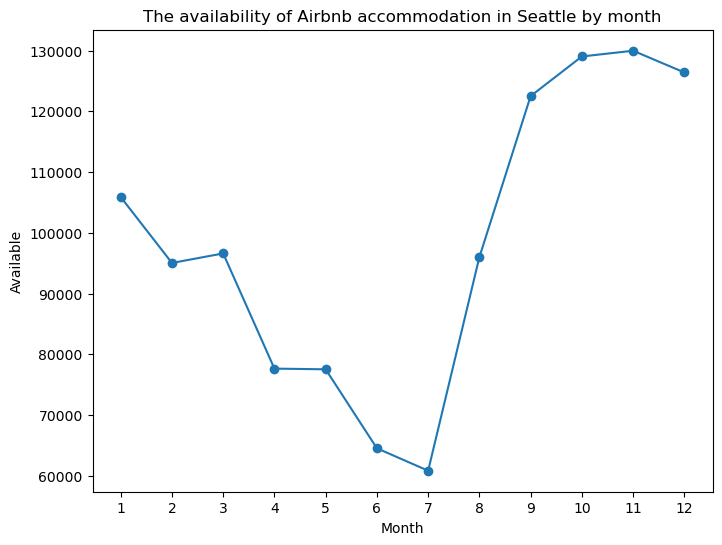

In [27]:
availability_by_month = pd.DataFrame(temp)

fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(availability_by_month['month'], availability_by_month['available'])
ax.plot(availability_by_month['month'], availability_by_month['available'])
ax.set_xticks(range(1, 13))
ax.set_xlabel('Month')
ax.set_ylabel('Available')
ax.set_title('The availability of Airbnb accommodation in Seattle by month')
plt.show()

We can see that tourists prefer to visit Seattle in warm season particularly in July, but Seattle in the cold season (from September to February) is not considered to be a popular place.

**5. Which accomodations in a certain area/of a certain room type are popular among Seattle visitors?**

In [28]:
%%sql
drop function if exists check_popular_property(text);

create or replace function check_popular_property(feature text)
returns table (
    id bigint,
    name text,
    neighbourhood_group text,
    neighbourhood text,
    room_type text,
    price money,
    availability_365 int
) as $$
begin
    return query
    select l.id, l.name, l.neighbourhood_group, l.neighbourhood,l.room_type, l.price, l.availability_365
    from listings l
    where l.neighbourhood_group=feature or l.room_type=feature
    order by l.availability_365
    limit 3;
end;
$$ language plpgsql;

 * postgresql://postgres@localhost:5432/seattle_airbnb
Done.
Done.


[]

In [29]:
%sql SELECT DISTINCT neighbourhood_group FROM listings;

 * postgresql://postgres@localhost:5432/seattle_airbnb
17 rows affected.


neighbourhood_group
Downtown
Other neighborhoods
Cascade
Northgate
Central Area
Ballard
University District
Lake City
Delridge
Capitol Hill


In [30]:
%%sql
select * from check_popular_property('Downtown')

 * postgresql://postgres@localhost:5432/seattle_airbnb
3 rows affected.


id,name,neighbourhood_group,neighbourhood,room_type,price,availability_365
17510283,Space Needle View Condo w/ Free Parking & Laundry,Downtown,Belltown,Entire home/apt,$160.00,0
42681629,"Blueground | S. Lake Union, fitness & rooftop",Downtown,Belltown,Entire home/apt,$413.00,0
873663321487064456,"Blueground | S Lake Union, gym & storage, nr parks",Downtown,Belltown,Entire home/apt,$166.00,0


In [31]:
%sql SELECT DISTINCT room_type FROM listings;

 * postgresql://postgres@localhost:5432/seattle_airbnb
4 rows affected.


room_type
Entire home/apt
Shared room
Private room
Hotel room


In [32]:
%%sql
SELECT * FROM check_popular_property('Entire home/apt');

 * postgresql://postgres@localhost:5432/seattle_airbnb
3 rows affected.


id,name,neighbourhood_group,neighbourhood,room_type,price,availability_365
2995996,The Blue House on Thomas Corner in Madison Valley,Central Area,Mann,Entire home/apt,$399.00,0
6797786,Spacious & bright 2br mid-century,Other neighborhoods,Broadview,Entire home/apt,$135.00,0
8870139,The Carriage House,Northgate,North College Park,Entire home/apt,$75.00,0


**6. Which neighbourhood/room type is most/least popular among Seattle visitors?**

In [33]:
%%sql
WITH stats AS (
    SELECT neighbourhood_group, AVG(availability_365)::NUMERIC(6, 2)
    FROM listings
    GROUP BY neighbourhood_group
    ORDER BY AVG(availability_365)
)
(
    SELECT *
    FROM stats
    WHERE avg = (SELECT MIN(avg) FROM stats)
) UNION ALL
(
    SELECT *
    FROM stats
    WHERE avg = (SELECT MAX(avg) FROM stats)
);

 * postgresql://postgres@localhost:5432/seattle_airbnb
2 rows affected.


neighbourhood_group,avg
Beacon Hill,152.17
Cascade,234.04


In [34]:
%%sql
WITH stats AS (
    SELECT room_type, AVG(availability_365)::NUMERIC(6, 2)
    FROM listings
    GROUP BY room_type
    ORDER BY AVG(availability_365)
)
(
    SELECT *
    FROM stats
    WHERE avg = (SELECT MIN(avg) FROM stats)
) UNION ALL
(
    SELECT *
    FROM stats
    WHERE avg = (SELECT MAX(avg) FROM stats)
);

 * postgresql://postgres@localhost:5432/seattle_airbnb
2 rows affected.


room_type,avg
Entire home/apt,181.34
Hotel room,316.10


In [35]:
%%sql
SELECT neighbourhood_group, AVG(availability_365)::NUMERIC(6, 2)
FROM listings
GROUP BY neighbourhood_group
ORDER BY AVG(availability_365)

 * postgresql://postgres@localhost:5432/seattle_airbnb
17 rows affected.


neighbourhood_group,avg
Beacon Hill,152.17
Seward Park,162.65
Magnolia,164.21
Northgate,167.11
Lake City,168.15
Other neighborhoods,169.46
West Seattle,171.38
Rainier Valley,171.99
Ballard,173.93
Delridge,179.88


**7. A function to check the availability and price of a property on certain date.**

In [36]:
%%sql

DROP FUNCTION IF EXISTS check_availability(TEXT, DATE);

CREATE OR REPLACE FUNCTION check_availability(accommodation TEXT, available_date DATE)
RETURNS TABLE (
    name TEXT,
    booking_date DATE,
    available BOOLEAN,
    room_type TEXT,
    price MONEY
) AS $$
BEGIN
    RETURN QUERY
    SELECT l.name, c.date AS booking_date, c.available, l.room_type, c.price
    FROM listings l
    JOIN calendar c
    ON l.id = c.listing_id
    WHERE l.name=accommodation AND c.date=available_date;
END;
$$ LANGUAGE plpgsql;

 * postgresql://postgres@localhost:5432/seattle_airbnb
Done.
Done.


[]

In [37]:
%sql SELECT * FROM check_availability('spacious, great location w view', '2024-12-29');

 * postgresql://postgres@localhost:5432/seattle_airbnb
1 rows affected.


name,booking_date,available,room_type,price
"spacious, great location w view",2024-12-29,True,Entire home/apt,$200.00


**8. Get properties in a certain neighbourhood with prices in the given range on the specific date**

In [38]:
%%sql
DROP FUNCTION IF EXISTS check_properties(TEXT, BIGINT, BIGINT);

CREATE OR REPLACE FUNCTION check_properties(region TEXT, min_price BIGINT, max_price BIGINT, available_date DATE)
RETURNS TABLE (
    name TEXT,
    neighbourhood_group TEXT,
    booking_date DATE,
    room_type TEXT,
    price MONEY
) AS $$
BEGIN
    RETURN QUERY
    SELECT l.name, l.neighbourhood_group, c.date AS booking_date, l.room_type, c.price
    FROM listings l
    JOIN calendar c
    ON l.id=c.listing_id
    WHERE l.neighbourhood_group=region AND c.date=available_date AND (c.price::NUMERIC) >= min_price AND (c.price::NUMERIC) <=max_price
    ORDER BY c.price::NUMERIC;
END;
$$ LANGUAGE plpgsql;

 * postgresql://postgres@localhost:5432/seattle_airbnb
Done.
Done.


[]

In [39]:
%%sql 
SELECT * FROM check_properties('Ballard', 100, 200, '2024-12-29')
LIMIT 10;

 * postgresql://postgres@localhost:5432/seattle_airbnb
10 rows affected.


name,neighbourhood_group,booking_date,room_type,price
Quiet & Cozy Apartment in Ballard,Ballard,2024-12-29,Entire home/apt,$100.00
Cloud Nest Penthouse Master Bedroom,Ballard,2024-12-29,Private room,$100.00
Ballard getaway with entire downstairs for you,Ballard,2024-12-29,Private room,$100.00
Minutes Walk to Ballard Ave!,Ballard,2024-12-29,Entire home/apt,$100.00
Two Bedrooms First Floor - Modern Ballard Townhome,Ballard,2024-12-29,Private room,$100.00
Fam friendly townhouse with Peloton! Near it all.,Ballard,2024-12-29,Entire home/apt,$100.00
Private Master Bedroom in a modern house,Ballard,2024-12-29,Private room,$100.00
Ground floor private bed/bath in Ballard,Ballard,2024-12-29,Private room,$100.00
"Quiet, Private Guest Suite in Sunset Hill Ballard",Ballard,2024-12-29,Entire home/apt,$100.00
Cozy Ballard Get Away,Ballard,2024-12-29,Entire home/apt,$100.00


**9. The total number of reviews received by each Airbnb host.**

In [40]:
%%sql
reviews_per_host <<
WITH by_property AS (
    SELECT DISTINCT listing_id, COUNT(*) OVER(PARTITION BY listing_id)
    FROM reviews
)
SELECT l.host_id, SUM(b.count) as total_reviews
FROM listings l
JOIN by_property b
ON l.id=b.listing_id
GROUP BY l.host_id
ORDER BY total_reviews DESC;


 * postgresql://postgres@localhost:5432/seattle_airbnb
3143 rows affected.
Returning data to local variable reviews_per_host


In [41]:
reviews_per_host = pd.DataFrame(reviews_per_host)
reviews_per_host.head(10)

,host_id,total_reviews
0,340706410,5557
1,398317720,4409
2,86157147,3323
3,17269911,3034
4,4730169,2932
5,80333752,2880
6,3074414,2638
7,28420265,2578
8,54812088,2472
9,9840816,2400
